In [47]:
import pandas as pd

dataset = pd.read_csv(r"C:\Users\gurra\HIERARCHICALCLUSTERING\Mall_Customers.csv")
dataset.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [48]:
import scipy.cluster.hierarchy as sch

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [50]:
dataset.isna().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [51]:
x=dataset.iloc[:,3:].values
x

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

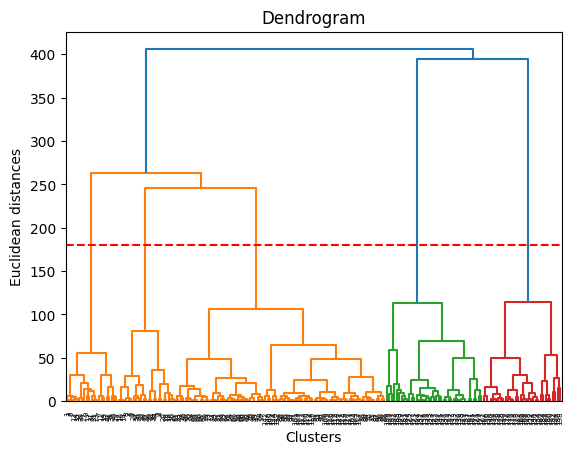

In [52]:
dendogram=sch.dendrogram(sch.linkage(x, method='ward'))
plt.axhline(y=180, color='r',linestyle='--')
plt.title('Dendrogram')
plt.xlabel('Clusters')
plt.ylabel('Euclidean distances')
plt.show()

In [54]:
from sklearn.cluster import AgglomerativeClustering
hc=AgglomerativeClustering(n_clusters=5, metric='euclidean',linkage='ward')

y_hc=hc.fit_predict(x)
y_hc

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 1,
       4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 0, 2, 0, 2,
       1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2])

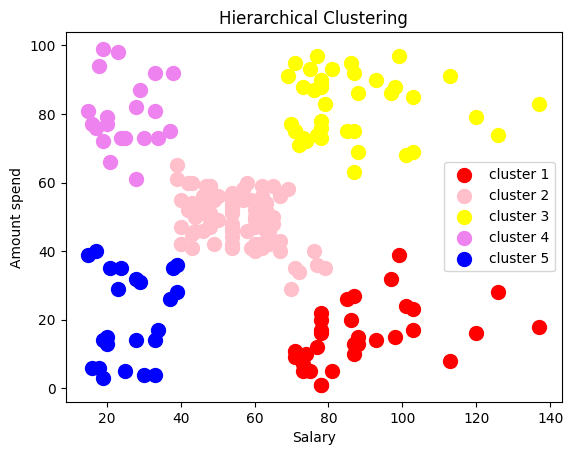

In [55]:
plt.scatter(x[y_hc==0 , 0] , x[y_hc==0 , 1] , s=100 , c='red' , label='cluster 1')
plt.scatter(x[y_hc==1 , 0] , x[y_hc==1 , 1] , s=100 , c='pink' , label='cluster 2')
plt.scatter(x[y_hc==2 , 0] , x[y_hc==2 , 1] , s=100 , c='yellow' , label='cluster 3')
plt.scatter(x[y_hc==3 , 0] , x[y_hc==3 , 1] , s=100 , c='violet' , label='cluster 4')
plt.scatter(x[y_hc==4 , 0] , x[y_hc==4 , 1] , s=100 , c='blue' , label='cluster 5')
plt.xlabel('Salary')
plt.ylabel('Amount spend')
plt.title('Hierarchical Clustering')
plt.legend()
plt.show()

In [56]:
from sklearn.metrics import silhouette_score
score=silhouette_score(x,y_hc)
print("Silhouette Score for Hierarchical Clustering",score)

Silhouette Score for Hierarchical Clustering 0.5529945955148897


In [71]:
import pandas as pd

dataset = pd.read_csv(r"C:\Users\gurra\HierarchicalClustering\all-data.csv",encoding='latin1')
dataset.head()

,neutral,"According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing ."
0,neutral,Technopolis plans to develop in stages an area...
1,negative,The international electronic industry company ...
2,positive,With the new production plant the company woul...
3,positive,According to the company 's updated strategy f...
4,positive,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...


In [72]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [73]:
from sklearn.decomposition import PCA

In [74]:
dataset.columns = ['Sentiment', 'News']

In [75]:
texts = dataset['News']

In [76]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=500)
X = vectorizer.fit_transform(texts)
X_dense = X.toarray()

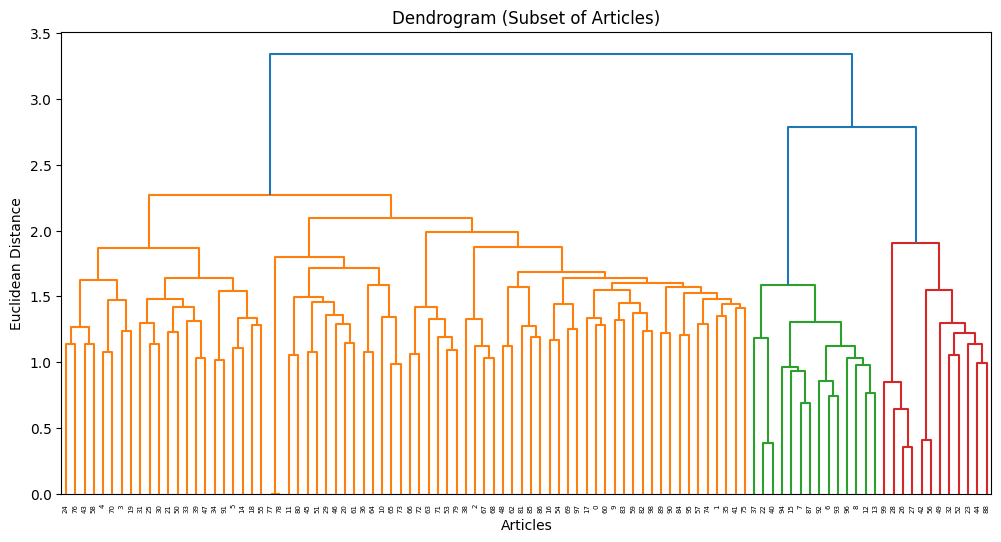

In [77]:
subset=X_dense[:100]
plt.figure(figsize=(12,6))
dendogram=sch.dendrogram(
    sch.linkage(subset,method='ward')
)
plt.title("Dendrogram (Subset of Articles)")
plt.xlabel("Articles")
plt.ylabel("Euclidean Distance")
plt.show()

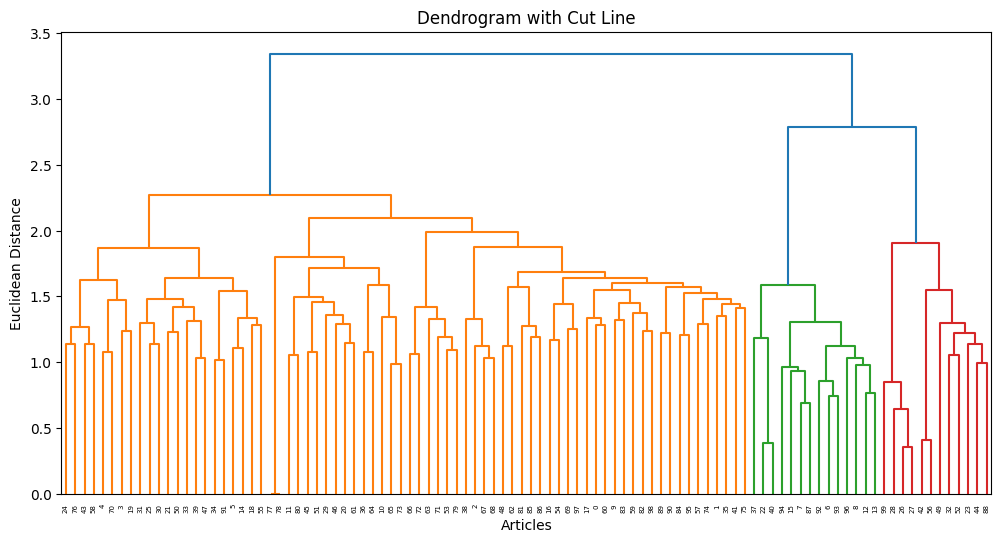

In [78]:
plt.figure(figsize=(12,6))
Z=sch.linkage(subset,method='ward')
sch.dendrogram(Z)
plt.title("Dendrogram with Cut Line")
plt.xlabel("Articles")
plt.ylabel("Euclidean Distance")
plt.show()

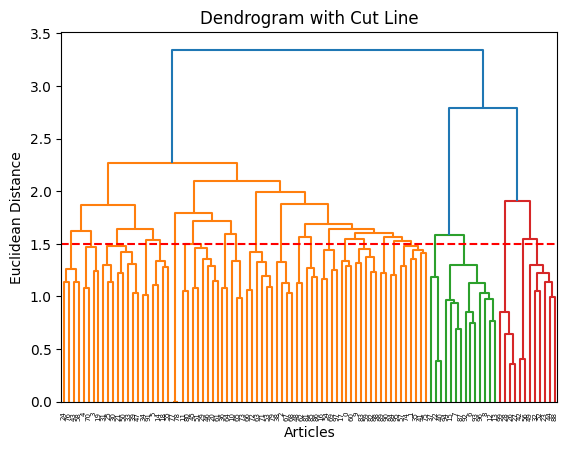

In [79]:
Z=sch.linkage(subset,method='ward')
sch.dendrogram(Z)
plt.axhline(y=1.5, color='r', linestyle='--')
plt.title("Dendrogram with Cut Line")
plt.xlabel("Articles")
plt.ylabel("Euclidean Distance")
plt.show()

In [80]:
n_clusters=5
model=AgglomerativeClustering(
    n_clusters=n_clusters,
    linkage='ward'
)
labels=model.fit_predict(X_dense)

In [81]:
score=silhouette_score(X_dense, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.015835476508968768


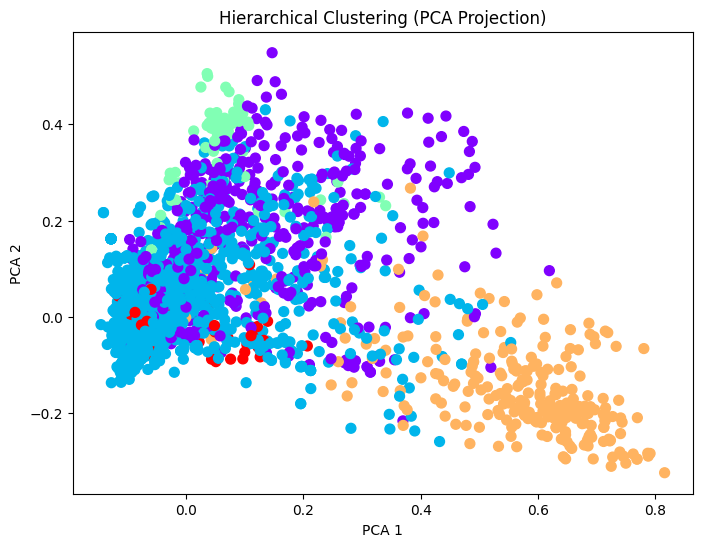

In [82]:
pca=PCA(n_components=2)
X_reduced=pca.fit_transform(X_dense)
plt.figure(figsize=(8,6))
plt.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    c=labels,
    cmap='rainbow',
    s=50
)
plt.title("Hierarchical Clustering (PCA Projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [83]:
feature_names = vectorizer.get_feature_names_out()
 
for cluster in range(n_clusters):
    print(f"\nCluster {cluster}")
   
    cluster_indices = np.where(labels == cluster)
    cluster_tfidf = X_dense[cluster_indices]
   
    mean_tfidf = np.mean(cluster_tfidf, axis=0)
    top_indices = mean_tfidf.argsort()[-10:][::-1]
   
    top_words = [feature_names[i] for i in top_indices]
    print("Top Words:", top_words)


Cluster 0
Top Words: ['million', 'eur', 'net', 'sales', 'year', 'profit', 'quarter', 'percent', 'period', '2010']

Cluster 1
Top Words: ['company', 'said', 'finland', 'new', 'finnish', 'business', 'group', 'market', 'services', 'sales']

Cluster 2
Top Words: ['mln', 'euro', 'net', '2006', 'profit', '2007', 'sales', '2005', 'finnish', 'oyj']

Cluster 3
Top Words: ['mn', 'eur', 'profit', 'operating', 'period', 'corresponding', 'compared', 'loss', 'totalled', 'quarter']

Cluster 4
Top Words: ['shares', 'capital', 'share', 'rights', 'number', 'voting', 'following', 'total', 'eur', 'increase']


In [86]:
import pandas as pd

dataset = pd.read_csv(r"C:\Users\gurra\HIERARCHICALCLUSTERING\Mall_Customers.csv")
dataset.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [87]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [103]:
X=dataset[['Annual Income (k$)', 'Spending Score (1-100)']]
X

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


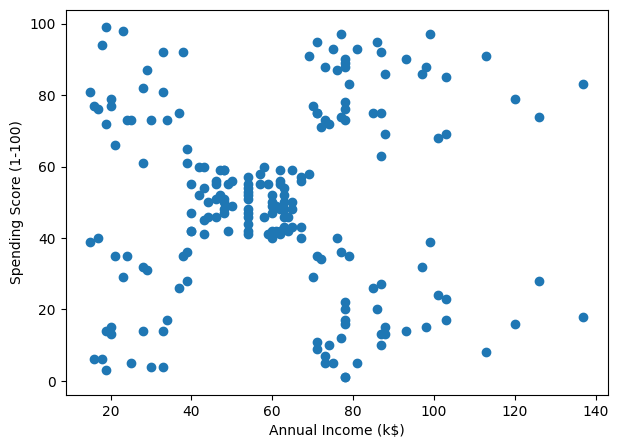

In [104]:
plt.figure(figsize=(7,5))
plt.scatter(X['Annual Income (k$)'],X['Spending Score (1-100)'])
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [105]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [111]:
dbscan=DBSCAN(eps=0.5,min_samples=5)
clusters=dbscan.fit_predict(X_scaled)

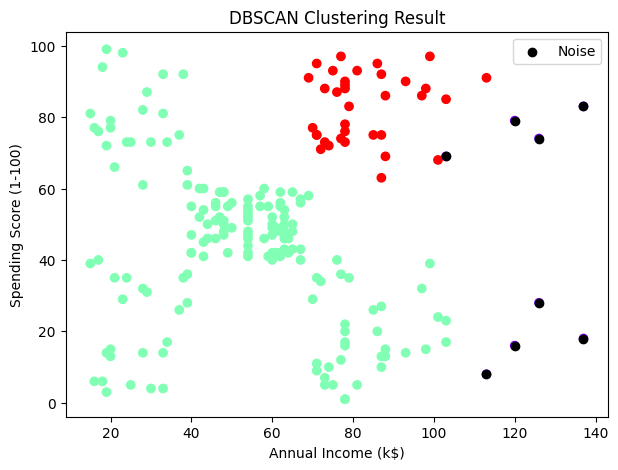

In [ ]:
plt.figure(figsize=(7,5))
# Plot all points with cluster colors
plt.scatter(
    X['Annual Income (k$)'],X['Spending Score (1-100)'],c=clusters,
    cmap='rainbow')
# Plot noise points separately
plt.scatter(
    X.loc[clusters == -1, 'Annual Income (k$)'],X.loc[clusters == -1, 'Spending Score (1-100)'],
    color='black',label='Noise')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.title("DBSCAN Clustering Result")
plt.show()

In [113]:
eps_value=[0.2,0.3,0.5]
for eps in eps_value:
    print(f"\n Evaluating DBSCAN using eps={eps}")
    dbscan=DBSCAN(eps=eps,min_samples=5)
    labels=dbscan.fit_predict(X_scaled)
    unique_labels=set(labels)
    n_clusters=len(unique_labels)-(1 if -1 in unique_labels else 0)
    n_noise=list(labels).count(-1)
    noise_ratio=n_noise/len(labels)
    print(f"Number of Clusters: {n_clusters}")
    print(f"Number of Noise Points:",round(noise_ratio,2))
    if n_clusters>1:
        X_non_noise=X_scaled[labels != -1]
        labels_non_noise=labels[labels != -1]
        score=silhouette_score(X_non_noise, labels_non_noise)
        print("Silhouette score:", round(score, 3))
    else:
        print("Silhouette score: Not applicable")

    


 Evaluating DBSCAN using eps=0.2
Number of Clusters: 7
Number of Noise Points: 0.39
Silhouette score: 0.586

 Evaluating DBSCAN using eps=0.3
Number of Clusters: 7
Number of Noise Points: 0.17
Silhouette score: 0.524

 Evaluating DBSCAN using eps=0.5
Number of Clusters: 2
Number of Noise Points: 0.04
Silhouette score: 0.388


1️⃣ Load the Dataset
Load the CSV file into a pandas DataFrame.
Display the first 5 rows of the dataset.
2️⃣ Feature Selection
Extract the following columns:
pickup_latitude
pickup_longitude
Store them in a variable named X.
3️⃣ Data Preprocessing
Apply StandardScaler to scale the selected features.
Store the scaled data in X_scaled.
4️⃣ DBSCAN Model – Experiment 1
Apply DBSCAN with:
eps = 0.2
min_samples = 5
Store cluster labels in labels_1.
5️⃣ DBSCAN Model – Experiment 2
Apply DBSCAN with:
eps = 0.3
min_samples = 5
Store cluster labels in labels_2.
6️⃣ DBSCAN Model – Experiment 3
Apply DBSCAN with:
eps = 0.5
min_samples = 5
Store cluster labels in labels_3.
7️⃣ Cluster Evaluation
For each experiment:
Print:
Number of clusters (excluding noise)
Number of noise points
Noise ratio
8️⃣ Silhouette Score Calculation
Remove noise points (-1) from each experiment.
Calculate and print the Silhouette Score for:
Experiment 1
Experiment 2
Experiment 3
If silhouette score is not applicable, print "Not Applicable".
9️⃣ Visualization
For each experiment:
Plot pickup locations using a scatter plot.
Color points based on cluster labels.
Highlight noise points using a separate color.
🔟 Best Model Selection
Based on:
Number of clusters
Noise ratio
Silhouette score
Print:
Best eps value = ___

In [118]:
import pandas as pd

dataset = pd.read_csv(r"C:\Users\gurra\HIERARCHICALCLUSTERING\train.csv")
dataset = dataset.sample(10000, random_state=42)
dataset.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
67250,id2793718,2,2016-06-08 07:36:19,2016-06-08 07:53:39,1,-73.985611,40.735943,-73.980331,40.760468,N,1040
1397036,id3485529,2,2016-04-03 12:58:11,2016-04-03 13:11:58,1,-73.978394,40.764351,-73.991623,40.749859,N,827
1021087,id1816614,2,2016-06-05 02:49:13,2016-06-05 02:59:27,5,-73.989059,40.744389,-73.973381,40.748692,N,614
951424,id1050851,2,2016-05-05 17:18:27,2016-05-05 17:32:54,2,-73.990326,40.731136,-73.991264,40.748917,N,867
707882,id0140657,1,2016-05-12 17:43:38,2016-05-12 19:06:25,4,-73.789497,40.646675,-73.987137,40.759232,N,4967


In [119]:
X = dataset[['pickup_latitude', 'pickup_longitude']]


In [120]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [121]:
eps_values = [0.2, 0.3, 0.5]
labels_list = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)
    labels_list.append(labels)

labels_1, labels_2, labels_3 = labels_list

In [123]:
def evaluate(labels, X_scaled, exp_name):
    print(f"\n--- {exp_name} ---")

    unique_labels = set(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    n_noise = list(labels).count(-1)
    noise_ratio = n_noise / len(labels)

    print("Number of clusters:", n_clusters)
    print("Number of noise points:", n_noise)
    print("Noise ratio:", round(noise_ratio, 3))
    if n_clusters > 1:
        X_non_noise = X_scaled[labels != -1]
        labels_non_noise = labels[labels != -1]
        score = silhouette_score(X_non_noise, labels_non_noise)
        print("Silhouette Score:", round(score, 3))
        return score, noise_ratio, n_clusters
    else:
        print("Silhouette Score: Not Applicable")
        return None, noise_ratio, n_clusters

In [124]:
results = []

for i, labels in enumerate(labels_list):
    results.append(evaluate(labels, X_scaled, f"Experiment {i+1} (eps={eps_values[i]})"))


--- Experiment 1 (eps=0.2) ---
Number of clusters: 11
Number of noise points: 84
Noise ratio: 0.008
Silhouette Score: 0.187

--- Experiment 2 (eps=0.3) ---
Number of clusters: 3
Number of noise points: 54
Noise ratio: 0.005
Silhouette Score: 0.639

--- Experiment 3 (eps=0.5) ---
Number of clusters: 3
Number of noise points: 17
Noise ratio: 0.002
Silhouette Score: 0.645


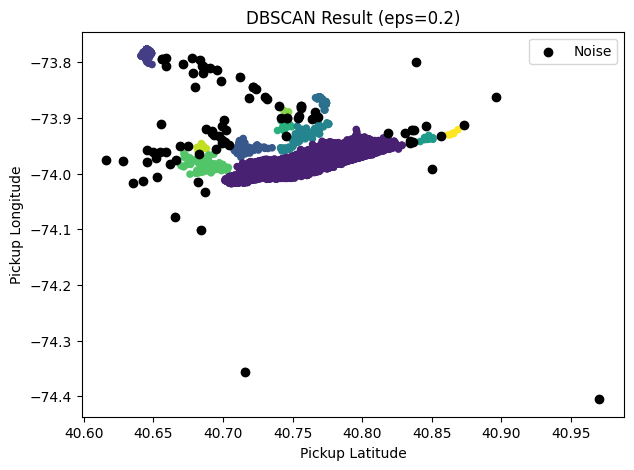

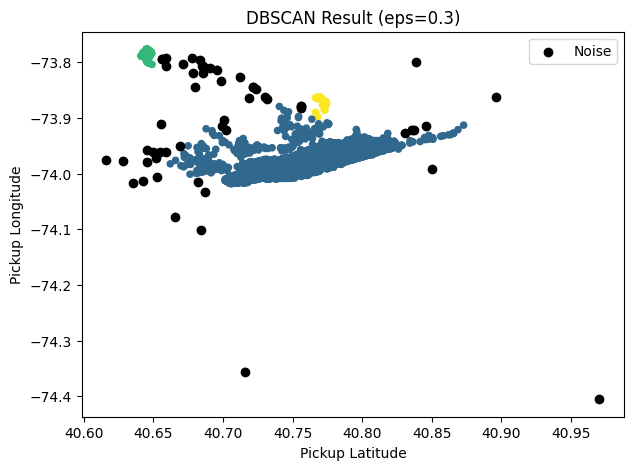

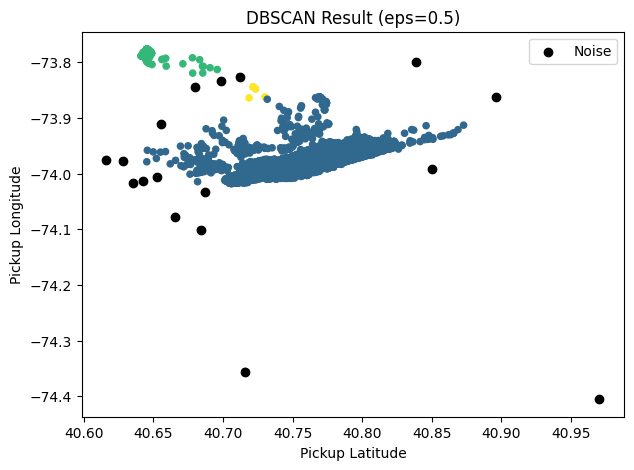

In [125]:
for i, labels in enumerate(labels_list):

    plt.figure(figsize=(7,5))

    plt.scatter(
        X['pickup_latitude'],
        X['pickup_longitude'],
        c=labels,
        s=20
    )

    # Noise points
    plt.scatter(
        X.loc[labels == -1, 'pickup_latitude'],
        X.loc[labels == -1, 'pickup_longitude'],
        color='black',
        label='Noise'
    )

    plt.title(f"DBSCAN Result (eps={eps_values[i]})")
    plt.xlabel("Pickup Latitude")
    plt.ylabel("Pickup Longitude")
    plt.legend()
    plt.show()


In [126]:
best_score = -1
best_eps = None

for i, res in enumerate(results):
    score = res[0]
    if score is not None and score > best_score:
        best_score = score
        best_eps = eps_values[i]

print("\nBest eps value =", best_eps)


Best eps value = 0.5
